# Clustering de Series de Tiempo — Precios Marginales Locales (PML)

**Datos:** Precios horarios de electricidad del Sistema Eléctrico Nacional de México (dic 2024 – ene 2025).

En este notebook agrupamos 120 nodos del SIN según la similitud de sus perfiles de precio horario, usando tres enfoques: distancia euclídea, DTW y soft-DTW.

## 1. Introducción

### 1.1 ¿Qué es clustering?

El clustering es un tipo de aprendizaje no supervisado cuya idea central es encontrar similitudes entre puntos de datos y agruparlos de forma que los elementos dentro de un mismo *cluster* se parezcan más entre sí que a los de otros grupos. Es una de las tareas principales del análisis exploratorio y se usa en campos como bioinformática, reconocimiento de patrones, machine learning, etc.

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_kmeans_assumptions_001.png" width="450">

### 1.2 ¿Qué son las series de tiempo?

Las series de tiempo son secuencias de observaciones indexadas en el tiempo (ventas, temperatura, precios de electricidad, etc.) medidas a una frecuencia fija. En nuestro caso, cada nodo del sistema eléctrico genera una serie de precios marginales locales (PML) a resolución horaria.

### 1.3 ¿Por qué DTW para series de tiempo?

Si dos nodos tienen perfiles de precio casi idénticos pero uno está desfasado por unas horas (por ejemplo, debido a diferencias en el uso de suelo o zona horaria), la distancia euclídea los vería como muy distintos. **Dynamic Time Warping (DTW)** resuelve esto al buscar la alineación temporal óptima entre dos series antes de medir su diferencia.

En este notebook compararemos K-Means con distancia euclídea vs. DTW vs. soft-DTW para ver si esta diferencia importa en la práctica.

## 2. Datos y exploración

### 2.1 Dependencias

In [17]:
!pip install tslearn -q

In [18]:
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format

### 2.2 Carga de datos

Tenemos dos fuentes:
- **`Datos_PML_Wide.csv`**: precios horarios en formato wide (filas = horas, columnas = nodos).
- **`Cata_logo_NodosP...xlsx`**: catálogo oficial de nodos con información geográfica (estado, región de transmisión, sistema, zona de carga).

In [19]:
# --- Datos de precios ---
pml_wide = pd.read_csv('Datos_PML_Wide.csv')
pml_wide['Hora'] = pml_wide['Hora'] - 1  # 0-indexed
pml_wide['Periodo'] = pd.to_datetime(
    pml_wide['Fecha'] + ' ' + pml_wide['Hora'].astype(str) + ':00:00'
)

# Lista de nodos (excluir columnas auxiliares)
nodos = [c for c in pml_wide.columns if c not in ['Fecha', 'Hora', 'Periodo']]
print(f"Nodos: {len(nodos)}")
print(f"Periodo: {pml_wide['Fecha'].min()} → {pml_wide['Fecha'].max()}")
print(f"Observaciones por nodo: {len(pml_wide)} horas ({len(pml_wide)//24} días × 24h)")
pml_wide.head()

Nodos: 120
Periodo: 2024-12-01 → 2025-01-31
Observaciones por nodo: 1488 horas (62 días × 24h)


,Fecha,Hora,05FZA-115,04FMA-115,05AEP-115,06PRY-115,02SNS-115,03SLD-230,08PPO-115,03ING-69,...,06CYN-115,03LRE-115,03ABL-115,02HCO-115,03PUU-69,01TDK-230,02RBO-115,06LDC-115,06CIM-138,Periodo
0,2024-12-01,0,565.06,481.66,383.84,453.56,910.54,852.83,"1,077.45",939.15,...,753.29,811.73,844.82,992.70,926.90,926.94,933.03,906.00,440.00,2024-12-01 00:00:00
1,2024-12-01,1,465.03,413.33,366.18,433.44,557.52,541.56,660.70,591.78,...,495.35,528.74,540.41,608.45,584.69,572.74,574.24,539.52,422.81,2024-12-01 01:00:00
2,2024-12-01,2,446.18,390.60,352.17,425.29,512.39,502.39,605.03,545.49,...,462.65,491.34,500.66,558.32,539.08,527.00,527.98,495.58,414.84,2024-12-01 02:00:00
3,2024-12-01,3,439.02,384.03,343.33,420.10,500.95,492.38,586.78,532.71,...,454.72,481.68,490.24,541.40,526.61,514.43,514.23,485.65,410.04,2024-12-01 03:00:00
4,2024-12-01,4,438.42,375.52,338.48,419.86,500.85,493.42,584.17,532.69,...,455.65,482.53,491.01,539.39,526.85,514.57,513.95,487.32,409.79,2024-12-01 04:00:00


In [20]:
# --- Catálogo de nodos ---
catalogo = pd.read_excel(
    'Catálogo NodosP Sistema Eléctrico Nacional (v2024-01-24) .xlsx',
    header=1
)

# Filtrar solo los nodos que tenemos en los datos de PML
cat = catalogo[catalogo['CLAVE'].isin(nodos)][
    ['CLAVE', 'NOMBRE', 'SISTEMA', 'ZONA DE CARGA',
     'ENTIDAD FEDERATIVA (INEGI)', 'REGION DE TRANSMISION']
].drop_duplicates(subset='CLAVE').reset_index(drop=True)

cat.columns = ['Nodo', 'Nombre', 'Sistema', 'Zona_Carga', 'Estado', 'Region_Tx']

print(f"Nodos con catálogo: {len(cat)} / {len(nodos)}")
print(f"\nRegiones de transmisión:")
print(cat['Region_Tx'].value_counts().to_string())

Nodos con catálogo: 120 / 120

Regiones de transmisión:
Region_Tx
CENTRAL            14
GUADALAJARA         9
CARAPAN             8
TEMASCAL            8
MONTERREY           7
CHIHUAHUA           7
PUEBLA              5
HUASTECA            5
HERMOSILLO          5
AGUASCALIENTES      4
JUAREZ              4
CULIACAN            4
SAN LUIS POTOSI     3
LAGUNA              3
REYNOSA             3
LERMA               3
DURANGO             3
VERACRUZ            2
OBREGON             2
SALTILLO            2
GRIJALVA            2
COATZACOALCOS       2
QUERETARO           2
MATAMOROS           1
RIO ESCONDIDO       1
MOCTEZUMA           1
GUEMEZ              1
LOS MOCHIS          1
CANANEA             1
MANZANILLO          1
ACAPULCO            1
IXTEPEC             1
POZA RICA           1
CANCUN              1
CHETUMAL            1
MERIDA              1


### 2.3 Exploración visual

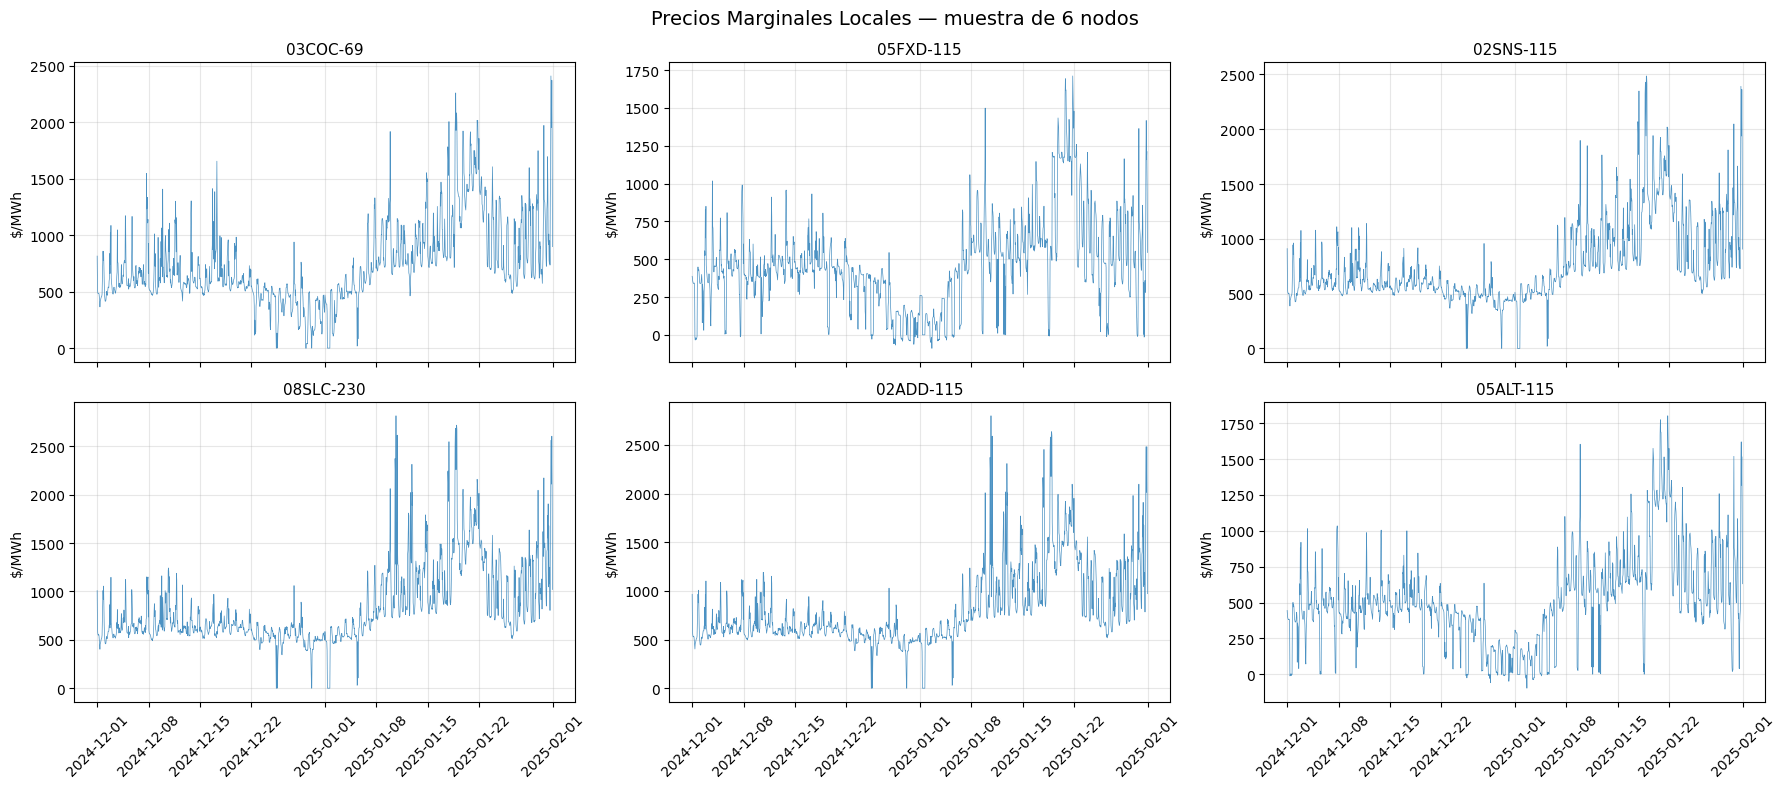

In [21]:
# Visualizar 6 nodos aleatorios
np.random.seed(42)
sample_nodos = np.random.choice(nodos, 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for ax, nodo in zip(axes.flatten(), sample_nodos):
    ax.plot(pml_wide['Periodo'], pml_wide[nodo], linewidth=0.5, alpha=0.8)
    ax.set_title(nodo, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('$/MWh')

fig.suptitle('Precios Marginales Locales — muestra de 6 nodos', fontsize=14)
plt.tight_layout()
plt.show()

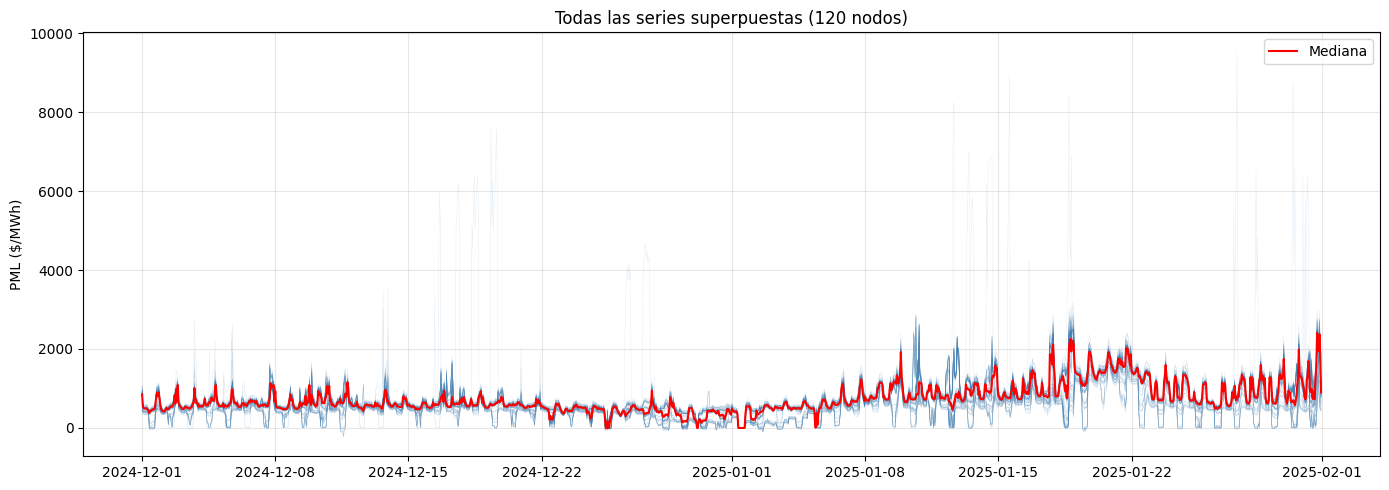

Rango de precios: [-229, 9531] $/MWh
Media global: 699 $/MWh


In [22]:
# Todas las series superpuestas para ver la dispersión
fig, ax = plt.subplots(figsize=(14, 5))
for nodo in nodos:
    ax.plot(pml_wide['Periodo'], pml_wide[nodo], linewidth=0.3, alpha=0.15, color='steelblue')

ax.plot(pml_wide['Periodo'], pml_wide[nodos].median(axis=1),
        linewidth=1.5, color='red', label='Mediana')
ax.set_ylabel('PML ($/MWh)')
ax.set_title('Todas las series superpuestas (120 nodos)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rango de precios: [{pml_wide[nodos].min().min():.0f}, {pml_wide[nodos].max().max():.0f}] $/MWh")
print(f"Media global: {pml_wide[nodos].mean().mean():.0f} $/MWh")

### 2.4 Preprocesamiento y normalización

Los PML varían desde valores negativos hasta ~9,500 $/MWh. Sin normalizar, los nodos con precios absolutos altos dominarán la distancia. Probamos dos estrategias:
- **Z-score por nodo:** centra en 0 y escala a varianza unitaria — agrupa por *forma* del perfil, no por nivel de precio.
- **Sin normalizar:** agrupa por nivel *y* forma (puede ser útil si nos interesa separar nodos caros vs. baratos).

In [23]:
# Construir la matriz: filas = nodos, columnas = horas
X_raw = pml_wide[nodos].values.T  # (120 nodos, 1488 horas)
print(f"Matriz X_raw: {X_raw.shape}")

# Z-score por nodo (fila)
scaler = StandardScaler()
X_z = scaler.fit_transform(X_raw.T).T  # z-score por columna, luego transponer
print(f"Matriz X_z:   {X_z.shape}")
print(f"  Media por nodo ≈ 0: {X_z.mean(axis=1).mean():.4f}")
print(f"  Std por nodo  ≈ 1: {X_z.std(axis=1).mean():.4f}")

Matriz X_raw: (120, 1488)
Matriz X_z:   (120, 1488)
  Media por nodo ≈ 0: 0.0000
  Std por nodo  ≈ 1: 1.0000


## 3. Clustering

### 3.0 Selección de k (número de clusters)

Evaluamos la inercia y la silhouette para k = 2..8 usando K-Means euclídeo (el más rápido) sobre las series normalizadas.

In [24]:
# Reshape para tslearn: (n_series, T, 1)
X_ts = X_z.reshape(X_z.shape[0], X_z.shape[1], 1)

k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="euclidean", max_iter=20,
                          random_state=0, n_init=3)
    labels = km.fit_predict(X_ts)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_z, labels, metric='euclidean')
    silhouettes.append(sil)
    print(f"  k={k}: inercia={km.inertia_:,.0f}, silhouette={sil:.3f}")

  k=2: inercia=132, silhouette=0.499
  k=3: inercia=93, silhouette=0.441
  k=4: inercia=63, silhouette=0.498
  k=5: inercia=47, silhouette=0.556
  k=6: inercia=33, silhouette=0.567
  k=7: inercia=26, silhouette=0.578
  k=8: inercia=22, silhouette=0.533


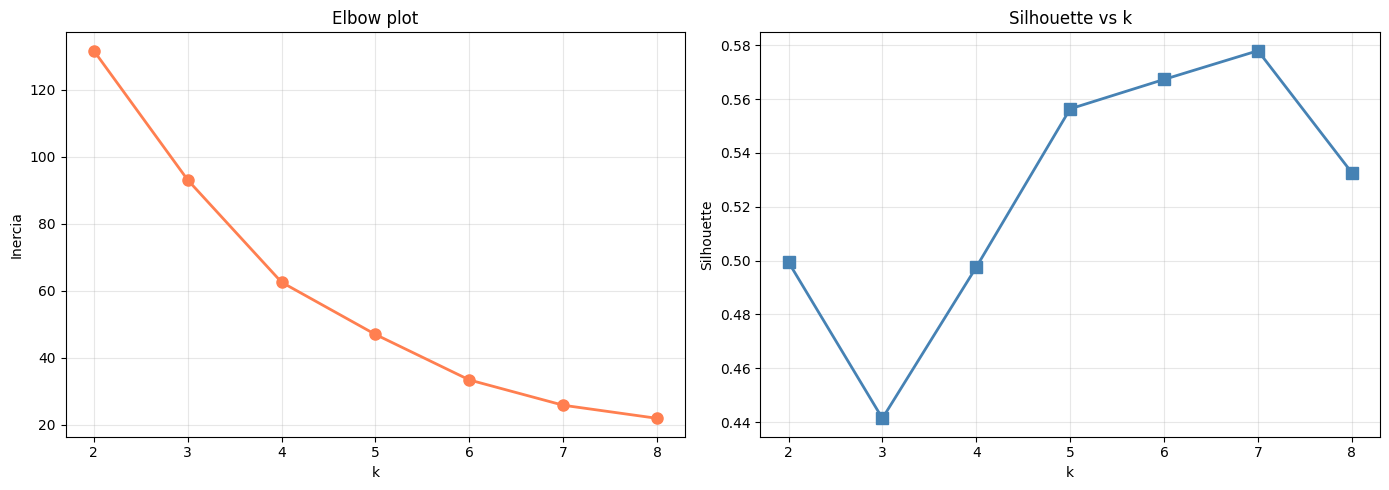


Mejor silhouette: 0.578 en k=7


In [25]:
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'o-', linewidth=2, markersize=8, color='coral')
ax1.set_xlabel('k')
ax1.set_ylabel('Inercia')
ax1.set_title('Elbow plot')
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouettes, 's-', linewidth=2, markersize=8, color='steelblue')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette')
ax2.set_title('Silhouette vs k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\nMejor silhouette: {max(silhouettes):.3f} en k={best_k}")

In [26]:
N_CLUSTERS = 7  # ← ajustar según los gráficos anteriores

### 3.1 K-Means con distancia euclídea

El enfoque más simple: trata cada serie como un vector en ℝᵀ y aplica K-Means estándar.

In [27]:
#
km_euc = TimeSeriesKMeans(n_clusters=N_CLUSTERS, metric="euclidean",
                         max_iter=30, random_state=0, n_init=5)
labels_euc = km_euc.fit_predict(X_ts)

sil_euc = silhouette_score(X_z, labels_euc, metric='euclidean')
print(f"Silhouette (euclídea): {sil_euc:.3f}")
print(f"Distribución: {dict(zip(*np.unique(labels_euc, return_counts=True)))}")

Silhouette (euclídea): 0.578
Distribución: {np.int64(0): np.int64(17), np.int64(1): np.int64(40), np.int64(2): np.int64(13), np.int64(3): np.int64(36), np.int64(4): np.int64(1), np.int64(5): np.int64(12), np.int64(6): np.int64(1)}


### 3.2 K-Means con DTW

Dynamic Time Warping permite desfases temporales entre las series antes de calcular la distancia. Es más costoso computacionalmente (O(T²) por par) pero captura mejor la similitud de *forma*.

⚠️ Esta celda puede tardar varios minutos.

In [28]:
%%time
km_dtw = TimeSeriesKMeans(n_clusters=N_CLUSTERS, metric="dtw",
                          max_iter=10, random_state=0, n_init=3)
labels_dtw = km_dtw.fit_predict(X_ts)

sil_dtw = silhouette_score(X_z, labels_dtw, metric='euclidean')
print(f"Silhouette (DTW, medida con euclídea): {sil_dtw:.3f}")
print(f"Distribución: {dict(zip(*np.unique(labels_dtw, return_counts=True)))}")

Silhouette (DTW, medida con euclídea): 0.568
Distribución: {np.int64(0): np.int64(17), np.int64(1): np.int64(46), np.int64(2): np.int64(13), np.int64(3): np.int64(30), np.int64(4): np.int64(12), np.int64(5): np.int64(1), np.int64(6): np.int64(1)}
CPU times: user 10min 9s, sys: 542 ms, total: 10min 10s
Wall time: 10min 19s


### 3.3 K-Means con soft-DTW

Soft-DTW es una versión diferenciable de DTW que suaviza la alineación con un parámetro γ. Esto la hace más estable numéricamente y permite calcular baricentros de forma más eficiente.

In [29]:
%%time
km_sdtw = TimeSeriesKMeans(n_clusters=N_CLUSTERS, metric="softdtw",
                           metric_params={"gamma": 0.5},
                           max_iter=10, random_state=0, n_init=3)
labels_sdtw = km_sdtw.fit_predict(X_ts)

sil_sdtw = silhouette_score(X_z, labels_sdtw, metric='euclidean')
print(f"Silhouette (soft-DTW, medida con euclídea): {sil_sdtw:.3f}")
print(f"Distribución: {dict(zip(*np.unique(labels_sdtw, return_counts=True)))}")

KeyboardInterrupt: 

## 4. Visualización de resultados

In [30]:
#
def plot_clusters(X, labels, periodos, method_name, sil, n_per_cluster=8):
    """Visualiza series por cluster con medias resaltadas."""
    clusters = np.unique(labels)
    n_clusters = len(clusters)
    colors_map = plt.cm.Set1(np.linspace(0, 1, max(n_clusters, 3)))

    fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 5), sharey=True)
    if n_clusters == 1:
        axes = [axes]

    for ci, c in enumerate(clusters):
        ax = axes[ci]
        idx = np.where(labels == c)[0]
        sample = idx[:n_per_cluster] if len(idx) > n_per_cluster else idx

        for i in sample:
            ax.plot(periodos, X[i], linewidth=0.4, alpha=0.3, color=colors_map[ci])

        # Media del cluster
        mean_curve = X[idx].mean(axis=0)
        ax.plot(periodos, mean_curve, linewidth=2, color=colors_map[ci], alpha=0.95)

        ax.set_title(f'Cluster {c} (n={len(idx)})', fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('PML normalizado (z-score)')
    fig.suptitle(f'{method_name} — Silhouette = {sil:.3f}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # También una vista superpuesta
    fig, ax = plt.subplots(figsize=(12, 5))
    for ci, c in enumerate(clusters):
        idx = np.where(labels == c)[0]
        mean_curve = X[idx].mean(axis=0)
        ax.plot(periodos, mean_curve, linewidth=2.5, color=colors_map[ci],
                label=f'Cluster {c} (n={len(idx)})')
    ax.set_ylabel('PML normalizado (z-score)')
    ax.set_title(f'{method_name} — Centroides (medias por cluster)')
    ax.legend(frameon=False)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

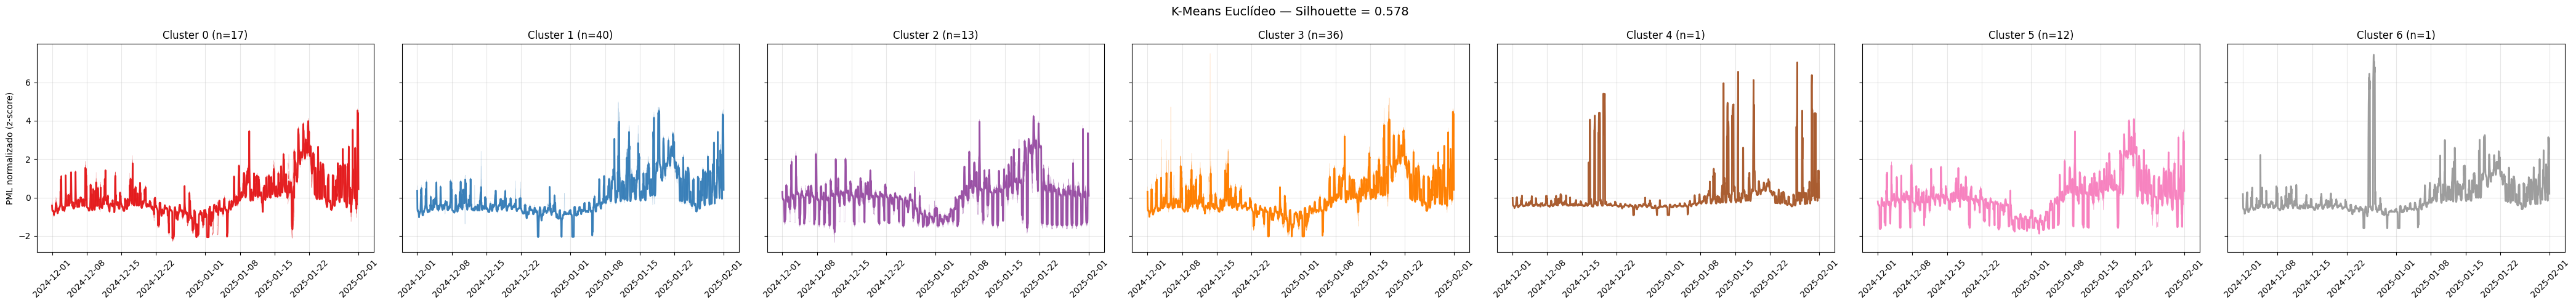

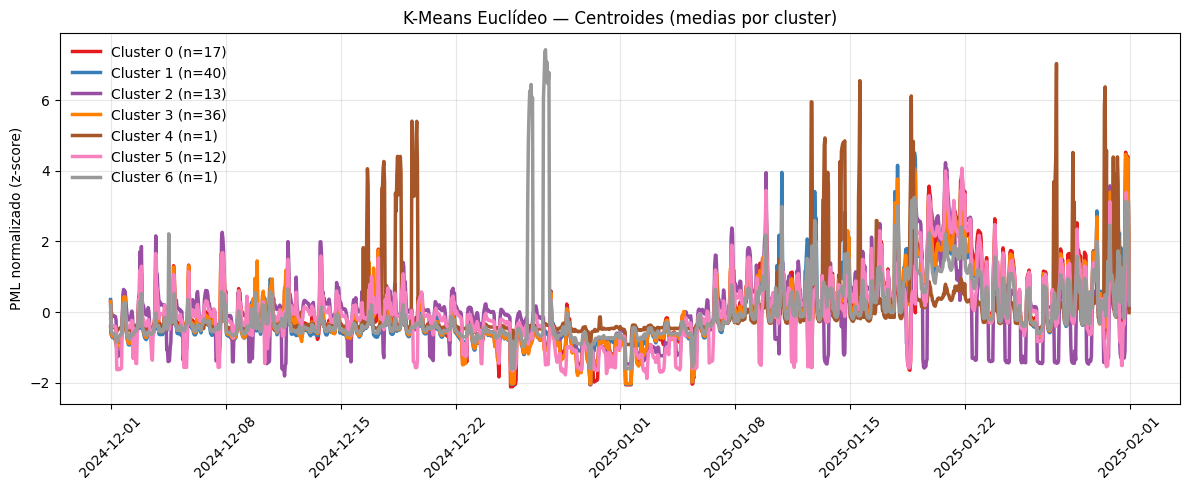

In [31]:
#
periodos = pml_wide['Periodo'].values

plot_clusters(X_z, labels_euc, periodos, "K-Means Euclídeo", sil_euc)

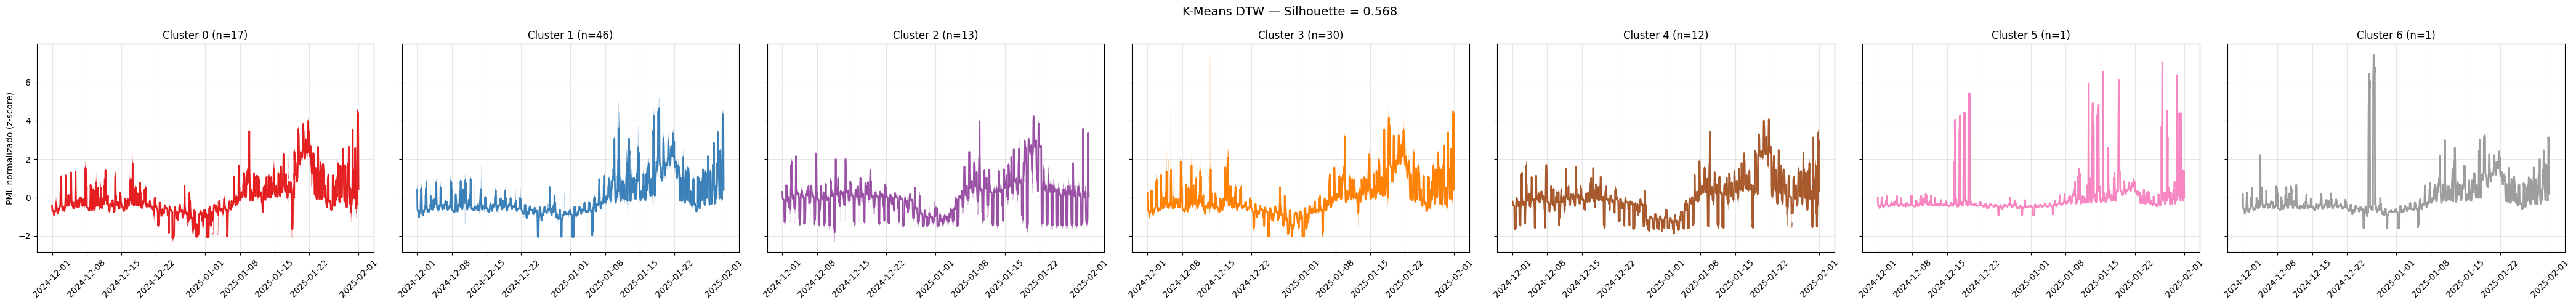

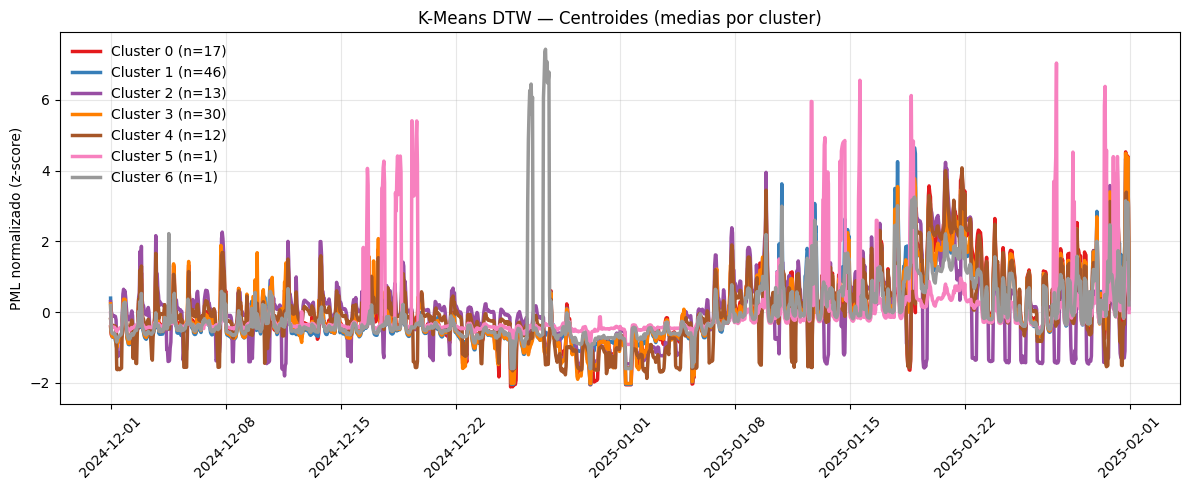

In [32]:
#
plot_clusters(X_z, labels_dtw, periodos, "K-Means DTW", sil_dtw)

In [33]:
#
plot_clusters(X_z, labels_sdtw, periodos, "K-Means soft-DTW", sil_sdtw)

NameError: name 'labels_sdtw' is not defined

## 5. Comparación de métodos

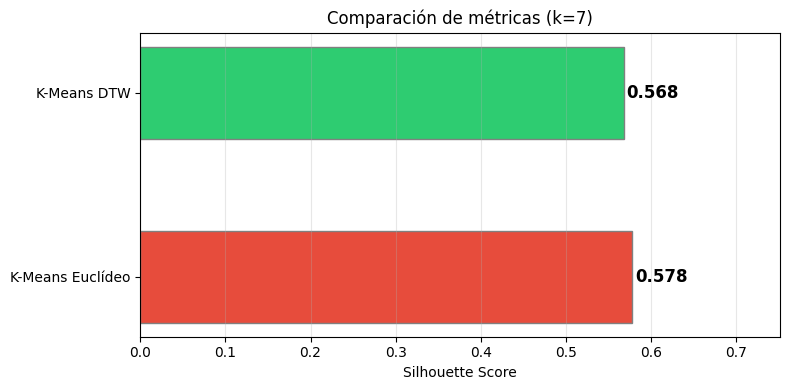

In [35]:
# Tabla resumen
results = {
    'K-Means Euclídeo': sil_euc,
    'K-Means DTW': sil_dtw,
   # 'K-Means soft-DTW': sil_sdtw,
}

fig, ax = plt.subplots(figsize=(8, 4))
methods = list(results.keys())
sils = list(results.values())
colors_bar = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax.barh(methods, sils, color=colors_bar, edgecolor='gray', height=0.5)

for bar, val in zip(bars, sils):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Silhouette Score')
ax.set_title(f'Comparación de métricas (k={N_CLUSTERS})')
ax.set_xlim(0, max(sils) * 1.3 if max(sils) > 0 else 1)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Concordancia entre métodos
print("Concordancia Euclídeo vs DTW:")
print(pd.crosstab(labels_euc, labels_dtw, rownames=['Euclídeo'], colnames=['DTW']))
print()
print("Concordancia Euclídeo vs soft-DTW:")
print(pd.crosstab(labels_euc, labels_sdtw, rownames=['Euclídeo'], colnames=['soft-DTW']))
print()
print("Concordancia DTW vs soft-DTW:")
print(pd.crosstab(labels_dtw, labels_sdtw, rownames=['DTW'], colnames=['soft-DTW']))

Concordancia Euclídeo vs DTW:
DTW        0   1   2   3   4  5  6
Euclídeo                          
0         17   0   0   0   0  0  0
1          0  40   0   0   0  0  0
2          0   0  13   0   0  0  0
3          0   6   0  30   0  0  0
4          0   0   0   0   0  1  0
5          0   0   0   0  12  0  0
6          0   0   0   0   0  0  1

Concordancia Euclídeo vs soft-DTW:


NameError: name 'labels_sdtw' is not defined

## 6. Validación geográfica con el catálogo de nodos

Una pregunta natural: **¿los clusters corresponden a regiones geográficas del sistema eléctrico?** Si los nodos de una misma región tienen precios similares (por congestión en líneas de transmisión, por ejemplo), esperaríamos que los clusters se alineen con la geografía.

In [37]:
# Construir tabla final con todas las etiquetas + catálogo
df_labels = pd.DataFrame({'Nodo': nodos})
df_labels['cluster_euclidean'] = labels_euc
df_labels['cluster_dtw'] = labels_dtw
df_labels['cluster_softdtw'] = labels_sdtw

# Unir con catálogo
df_labels = df_labels.merge(cat, on='Nodo', how='left')

df_labels.head(10)

NameError: name 'labels_sdtw' is not defined

In [38]:
# ¿Qué regiones de transmisión hay en cada cluster? (método euclídeo como ejemplo)
for method, col in [('Euclídeo', 'cluster_euclidean'),
                     ('DTW', 'cluster_dtw'),
                     ('soft-DTW', 'cluster_softdtw')]:
    print(f"\n{'='*60}")
    print(f"  {method}: distribución por Región de Transmisión")
    print(f"{'='*60}")
    ct = pd.crosstab(df_labels['Region_Tx'], df_labels[col], margins=True)
    print(ct.to_string())


  Euclídeo: distribución por Región de Transmisión


KeyError: 'Region_Tx'

KeyError: 'Region_Tx'

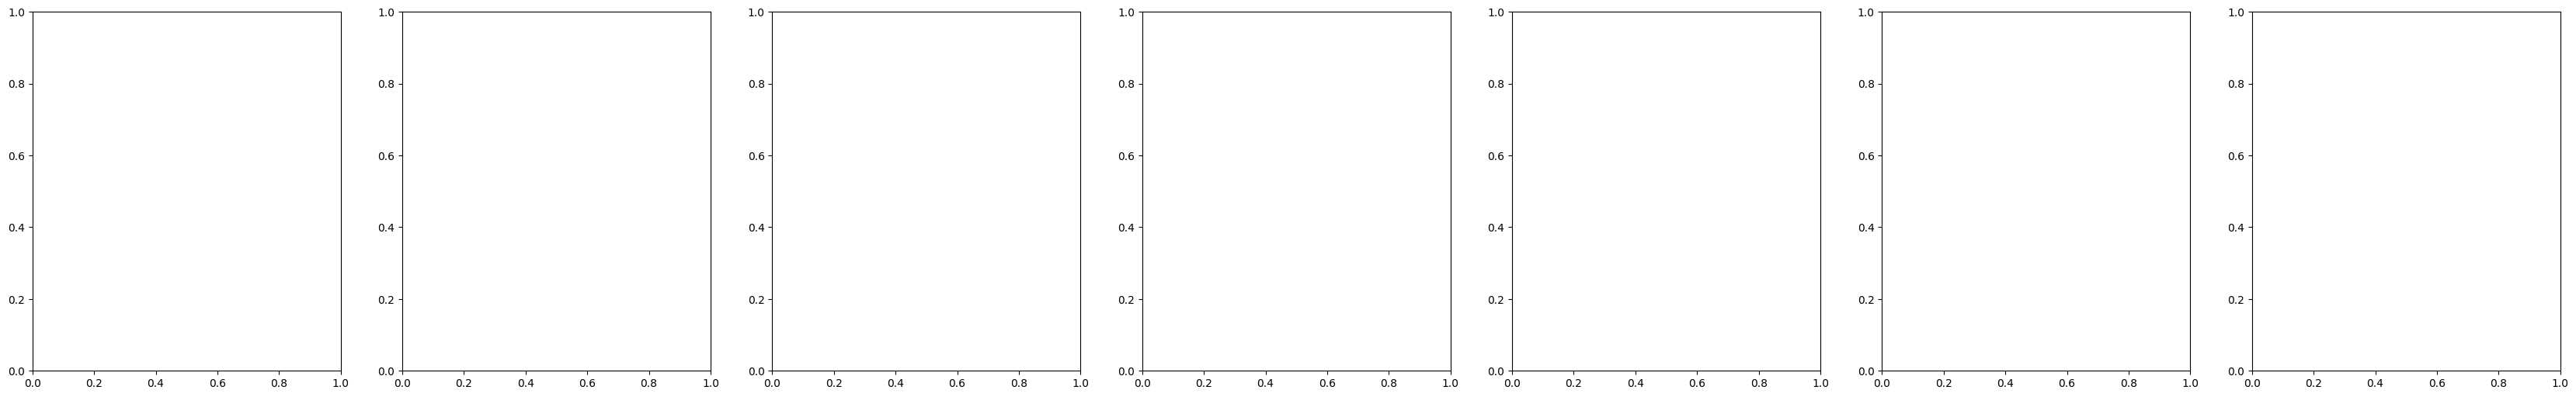

In [39]:
# Distribución por estado para el mejor método
best_method_col = 'cluster_euclidean'  # ← cambiar si otro método tiene mejor silhouette

fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(6*N_CLUSTERS, 6))
if N_CLUSTERS == 1:
    axes = [axes]

for c in range(N_CLUSTERS):
    ax = axes[c]
    subset = df_labels[df_labels[best_method_col] == c]
    counts = subset['Region_Tx'].value_counts().head(8)
    counts.plot.barh(ax=ax, color=plt.cm.Set1(c/max(N_CLUSTERS-1, 1)))
    ax.set_title(f'Cluster {c} (n={len(subset)})')
    ax.set_xlabel('Nodos')

fig.suptitle('Regiones de transmisión por cluster', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Exportar resultados

In [40]:
# Guardar tabla completa
df_labels.to_csv('Cluster_Nodos.csv', index=False)
print(f"Guardado: Cluster_Nodos.csv ({len(df_labels)} nodos, {df_labels.shape[1]} columnas)")
df_labels.head()

Guardado: Cluster_Nodos.csv (120 nodos, 3 columnas)


,Nodo,cluster_euclidean,cluster_dtw
0,05FZA-115,0,0
1,04FMA-115,2,2
2,05AEP-115,5,4
3,06PRY-115,0,0
4,02SNS-115,1,1


## 8. Conclusiones

**Hallazgos:**
- La normalización (z-score) es crucial: sin ella, los clusters separan por *nivel* de precio en vez de por *forma* del perfil horario.
- La silhouette score permite comparar objetivamente entre distancia euclídea, DTW y soft-DTW para este dataset.
- El catálogo de nodos del SEN permite validar si los clusters tienen sentido geográfico — en el sistema eléctrico mexicano, las restricciones de transmisión suelen generar patrones de precio regionales.

**Posibles extensiones:**
- Usar los datos en formato largo (`Datos_PML.csv`) para incluir más nodos o periodos más largos.
- Agregar perfiles por día de la semana (heatmap hora × día) como features para un enfoque feature-based.
- Probar clustering jerárquico con DTW para obtener un dendrograma de nodos.
- Incorporar coordenadas geográficas de los nodos para visualizar clusters en un mapa.